# Melting Point 예측 — v8_ann (Tautomer Augmentation + Stacking)

**v6_stacking 대비 차별점**:
1. **Tautomer enumeration** — 분자당 1~2 tautomer 추가, train 2x 증강
2. **Group-aware CV** — 같은 원본 분자의 tautomer가 같은 fold에 (GroupKFold)
3. **Target noise** — 학습 중 y_log에 N(0, 0.02) 추가 (실험 오차 모방)

**목표**: v6_stacking 0.7754 → 0.80~0.82

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn rdkit torch xgboost lightgbm -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from rdkit import Chem
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.MolStandardize import rdMolStandardize

from sklearn.model_selection import train_test_split, StratifiedKFold, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import xgboost as xgb
import lightgbm as lgb

import platform, subprocess
if platform.system() == 'Linux':
    subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], capture_output=True)
    import matplotlib.font_manager as fm
    fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
    plt.rcParams["font.family"] = "NanumGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T0 = time.time()
print("라이브러리 로드 완료")
print(f"디바이스: {DEVICE}")

라이브러리 로드 완료
디바이스: cpu


## 1. 데이터 로드

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/sunghee-sketch/middle-test/main/data/Melting_point_2.csv")
df = df.drop_duplicates().reset_index(drop=True)
df = df[df["MP"] >= 0].reset_index(drop=True)
df["MP_log"] = np.log1p(df["MP"])
print(f"데이터 크기: {df.shape}")
print(f"MP 범위: {df['MP'].min():.1f} ~ {df['MP'].max():.1f} K")
df.head()

데이터 크기: (2117, 3)
MP 범위: 13.9 ~ 1870.0 K


,SMILES,MP,MP_log
0,CCN(O)CC,247.650,5.516046
1,c1(C(C)=C)ccccc1,249.950,5.525254
2,C/C=C/CCCC,164.000,5.105945
3,c1(CC)cc(CC)cc(CC)c1,206.735,5.336263
4,COC(C)(C)C(=O)OC,229.600,5.440685


## 2. 원본 피처 추출 (Morgan + MACCS + RDKit) + Murcko Scaffold

In [4]:
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)
desc_list  = [(n, f) for n, f in Descriptors.descList if not n.startswith("Ipc")]

def smiles_to_features_and_scaffold(smiles_list):
    records, scaffolds, valid_idx = [], [], []
    for i, smi in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        morgan = morgan_gen.GetFingerprintAsNumPy(mol).astype(np.float32)
        maccs  = np.array(MACCSkeys.GenMACCSKeys(mol), dtype=np.float32)
        descs  = []
        for _, func in desc_list:
            try:
                v = func(mol)
                descs.append(float(v) if (v is not None and np.isfinite(v)) else 0.0)
            except Exception:
                descs.append(0.0)
        records.append(np.concatenate([morgan, maccs, np.array(descs, np.float32)]))
        # Murcko scaffold (빈 scaffold면 SMILES 자체 사용)
        try:
            scaf = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
            scaffolds.append(scaf if scaf else smi)
        except Exception:
            scaffolds.append(smi)
        valid_idx.append(i)
    X = np.array(records, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, scaffolds, valid_idx

print("피처 + scaffold 추출 중...")
t = time.time()
X_all, scaffolds_all, valid_idx = smiles_to_features_and_scaffold(df["SMILES"].tolist())
y_all     = df["MP"].values[valid_idx]
y_all_log = df["MP_log"].values[valid_idx]
scaf_arr  = np.array(scaffolds_all)
n_unique_scaf = len(set(scaffolds_all))
print(f"유효 샘플: {len(valid_idx)} / {len(df)}  |  피처 차원: {X_all.shape[1]}  |  소요: {time.time()-t:.1f}s")
print(f"Unique scaffold 수: {n_unique_scaf} (전체 분자의 {n_unique_scaf/len(valid_idx):.1%})")

피처 + scaffold 추출 중...
유효 샘플: 2117 / 2117  |  피처 차원: 2431  |  소요: 7.6s
Unique scaffold 수: 1527 (전체 분자의 72.1%)


## 3. VarianceThreshold + Train/Test 분할 (원본)

In [5]:
# VT fit on original
vt = VarianceThreshold(threshold=0.01)
X_all_vt = vt.fit_transform(X_all).astype(np.float32)
print(f"VT 전: {X_all.shape[1]} → 후: {X_all_vt.shape[1]}")

# Train/test split (원본 분자 기준)
mp_bins = pd.qcut(y_all, q=10, labels=False, duplicates="drop")
indices = np.arange(len(X_all_vt))
tr_i, te_i = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_STATE, stratify=mp_bins
)
print(f"Train: {len(tr_i)}  |  Test: {len(te_i)} (원본 기준)")

VT 전: 2431 → 후: 504
Train: 1693  |  Test: 424 (원본 기준)


## 4. Tautomer Augmentation (핵심 차별점)
- Train 분자 각각에 대해 RDKit `TautomerEnumerator`로 tautomer 생성
- 원본 포함 분자당 최대 2개 (원본 + alternative 1개)
- 같은 tautomer 그룹은 같은 `group_id`를 부여 → GroupKFold로 fold 분리 시 누수 방지
- **Test는 증강 없이 원본 그대로**

In [6]:
enumerator = rdMolStandardize.TautomerEnumerator()

def enumerate_tautomer_features(smiles_list, max_per_mol=1):
    """각 분자의 원본 + tautomer들의 feature 생성.
    Returns: features, list of (source_smiles, is_tautomer)."""
    records = []
    meta = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            continue
        try:
            tauts = list(enumerator.Enumerate(mol))
        except Exception:
            tauts = [mol]
        # 원본 mol을 대표로 첫번째에 넣고, 추가 tautomer max_per_mol개
        selected = [mol]
        for t in tauts:
            if len(selected) > max_per_mol:
                break
            t_smi = Chem.MolToSmiles(t)
            if t_smi != Chem.MolToSmiles(mol):
                selected.append(t)
        for k, m in enumerate(selected):
            morgan = morgan_gen.GetFingerprintAsNumPy(m).astype(np.float32)
            maccs  = np.array(MACCSkeys.GenMACCSKeys(m), dtype=np.float32)
            descs = []
            for _, func in desc_list:
                try:
                    v = func(m)
                    descs.append(float(v) if (v is not None and np.isfinite(v)) else 0.0)
                except Exception:
                    descs.append(0.0)
            records.append(np.concatenate([morgan, maccs, np.array(descs, np.float32)]))
            meta.append((smi, k > 0))  # (source, is_tautomer)
    X = np.array(records, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X, meta

# Train SMILES만 증강
train_smiles = [df['SMILES'].iloc[valid_idx[i]] for i in tr_i]
print(f"Train 원본 분자: {len(train_smiles)}")
print("Tautomer 증강 중... (1분 이내)")
t = time.time()
X_train_aug_raw, meta_train = enumerate_tautomer_features(train_smiles, max_per_mol=1)
print(f"증강 후 샘플: {X_train_aug_raw.shape[0]}  |  추가 tautomer: {X_train_aug_raw.shape[0] - len(train_smiles)}  ({time.time()-t:.0f}s)")

# 각 샘플에 group_id (원본 분자 index) 부여
smi_to_gid = {s: i for i, s in enumerate(train_smiles)}
group_ids = np.array([smi_to_gid[m[0]] for m in meta_train])

# y 라벨 할당 (tautomer는 원본과 같은 MP)
y_train_full = y_all[tr_i]
y_train_aug = np.array([y_train_full[group_ids[i]] for i in range(len(group_ids))])
y_tr_log_aug = np.log1p(y_train_aug).astype(np.float32)

# Sample weight (원본과 동일, tautomer는 같은 weight)
y_train_orig = y_all[tr_i]
high_thr = np.percentile(y_train_orig, 90)
sw_train_aug = np.where(y_train_aug >= high_thr, 3.0, 1.0).astype(np.float32)

# Scaffold for GroupKFold
scaf_train_aug = np.array([scaffolds_all[valid_idx[tr_i[gid]]] for gid in group_ids])

print(f"증강 train shape: X={X_train_aug_raw.shape}, y={y_train_aug.shape}")
print(f"Group 수 (원본 분자): {len(np.unique(group_ids))}")
print(f"평균 샘플/분자: {X_train_aug_raw.shape[0] / len(np.unique(group_ids)):.2f}")

Train 원본 분자: 1693
Tautomer 증강 중... (1분 이내)
증강 후 샘플: 2022  |  추가 tautomer: 329  (8s)
증강 train shape: X=(2022, 2431), y=(2022,)
Group 수 (원본 분자): 1682
평균 샘플/분자: 1.20


## 5. VT 적용 + Scaling (원본 VT 마스크 재사용)

In [7]:
# 원본 학습 데이터의 VT를 augmented에 적용
X_train_aug_vt = vt.transform(X_train_aug_raw).astype(np.float32)
X_test_raw = X_all[te_i]  # 원본 Test
X_test_vt = X_all_vt[te_i]

# Scaler fit on augmented train, apply to test
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_aug_vt).astype(np.float32)
X_test_sc = scaler.transform(X_test_vt).astype(np.float32)
X_train_sc = np.nan_to_num(X_train_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_test_sc = np.nan_to_num(X_test_sc, nan=0.0, posinf=0.0, neginf=0.0)
X_train_sc = np.clip(X_train_sc, -10.0, 10.0).astype(np.float32)
X_test_sc = np.clip(X_test_sc, -10.0, 10.0).astype(np.float32)

y_test = y_all[te_i]
y_te_log = y_all_log[te_i].astype(np.float32)

# Alias for compatibility
y_tr_log = y_tr_log_aug
y_train = y_train_aug  # for original-scale metrics
sw_train = sw_train_aug

print(f"Augmented Train scaled: {X_train_sc.shape}  |  Test scaled: {X_test_sc.shape}")

Augmented Train scaled: (2022, 504)  |  Test scaled: (424, 504)


## 6. MI top-K (augmented train 기준)

In [8]:
TOP_K = 300
print("Augmented train MI 계산 중...")
t = time.time()
mi_full = mutual_info_regression(X_train_sc, y_tr_log, random_state=RANDOM_STATE, n_neighbors=3)
top_idx_full = np.argsort(mi_full)[::-1][:TOP_K]
X_train_sel_full = X_train_sc[:, top_idx_full]
X_test_sel_full = X_test_sc[:, top_idx_full]
print(f"MI top-{TOP_K} 완료 ({time.time()-t:.1f}s)")
print(f"MI 상위 5 평균: {mi_full[top_idx_full[:5]].mean():.4f}  |  하위 5 평균: {mi_full[top_idx_full[-5:]].mean():.4f}")

Augmented train MI 계산 중...
MI top-300 완료 (1.7s)
MI 상위 5 평균: 0.4037  |  하위 5 평균: 0.1693


## 7. 모델 정의 — v5/v6 동일 + Target Noise 옵션
`train_epoch`에 `target_noise` 추가 (기본 σ=0.02 on log scale ≈ ±2~3K on original).

In [9]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.ln1 = nn.LayerNorm(dim)
        self.ln2 = nn.LayerNorm(dim)
        self.act = nn.SiLU()
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        h = self.drop(self.act(self.ln1(self.fc1(x))))
        h = self.ln2(self.fc2(h))
        return x + h

class ResidualMLP(nn.Module):
    def __init__(self, input_dim, hidden=256, n_blocks=3, dropout=0.3):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(input_dim, hidden), nn.LayerNorm(hidden))
        self.blocks = nn.ModuleList([ResidualBlock(hidden, dropout) for _ in range(n_blocks)])
        self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Linear(hidden, 64), nn.SiLU(), nn.Linear(64, 1))
    def forward(self, x):
        x = self.proj(x)
        for b in self.blocks:
            x = b(x)
        return self.head(x).squeeze(1)

def mixup_batch(X, y, w, alpha=0.3):
    if alpha <= 0:
        return X, y, w
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(X.size(0), device=X.device)
    return lam * X + (1-lam) * X[idx], lam * y + (1-lam) * y[idx], lam * w + (1-lam) * w[idx]

def train_epoch(model, loader, optimizer, criterion, mixup_alpha=0.3, mixup_prob=0.5, target_noise=0.02):
    model.train()
    total_loss = 0
    for X_b, y_b, w_b in loader:
        X_b, y_b, w_b = X_b.to(DEVICE), y_b.to(DEVICE), w_b.to(DEVICE)
        # Target noise (label smoothing) — v8 차별점
        if target_noise > 0:
            y_b = y_b + torch.randn_like(y_b) * target_noise
        if np.random.rand() < mixup_prob:
            X_b, y_b, w_b = mixup_batch(X_b, y_b, w_b, alpha=mixup_alpha)
        optimizer.zero_grad()
        pred = model(X_b)
        loss = (criterion(pred, y_b) * w_b).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def predict(model, X_sc):
    model.eval()
    return model(torch.tensor(X_sc).to(DEVICE)).cpu().numpy()

INPUT_DIM = TOP_K
n_params = sum(p.numel() for p in ResidualMLP(INPUT_DIM).parameters())
print(f"입력: {INPUT_DIM}  |  파라미터: {n_params:,}")
print("모델 정의 완료 (target_noise=0.02 추가)")

입력: 300  |  파라미터: 492,417
모델 정의 완료 (target_noise=0.02 추가)


## 8. 5-Fold CV (GroupKFold, ANN, OOF 수집)
같은 원본 분자의 tautomer가 같은 fold에 배치 → 누수 방지.

In [10]:
EPOCHS    = 200
BATCH     = 128
LR        = 1e-3
PATIENCE  = 25
WD        = 5e-4
MIXUP_A   = 0.3
MIXUP_P   = 0.5
SCH_PAT   = 10
TARGET_NOISE = 0.02

gkf = GroupKFold(n_splits=5)
splits = list(gkf.split(X_train_sc, y_tr_log, groups=group_ids))

ann_oof_log = np.full(len(X_train_sc), np.nan, dtype=np.float32)
cv_r2, cv_mse, cv_mae, fold_overlaps, fold_epochs = [], [], [], [], []

t_cv = time.time()
for fold, (tr_idx, val_idx) in enumerate(splits, 1):
    t_fold = time.time()
    # fold-내부 MI
    mi_fold = mutual_info_regression(
        X_train_sc[tr_idx], y_tr_log[tr_idx],
        random_state=RANDOM_STATE + fold, n_neighbors=3
    )
    top_idx_fold = np.argsort(mi_fold)[::-1][:TOP_K]
    overlap = len(set(top_idx_fold.tolist()) & set(top_idx_full.tolist())) / TOP_K
    fold_overlaps.append(overlap)

    X_tr = X_train_sc[tr_idx][:, top_idx_fold].astype(np.float32)
    X_val = X_train_sc[val_idx][:, top_idx_fold].astype(np.float32)
    y_tr, y_val = y_tr_log[tr_idx], y_tr_log[val_idx]
    sw_tr = sw_train[tr_idx]
    y_val_orig = y_train[val_idx]

    ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr), torch.tensor(sw_tr))
    ldr = DataLoader(ds, batch_size=BATCH, shuffle=True)

    torch.manual_seed(RANDOM_STATE + fold)
    np.random.seed(RANDOM_STATE + fold)
    model = ResidualMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.3).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=SCH_PAT, factor=0.5)
    criterion = nn.MSELoss(reduction="none")

    best_val_loss, patience_cnt, best_state = np.inf, 0, None
    for epoch in range(EPOCHS):
        train_epoch(model, ldr, optimizer, criterion, mixup_alpha=MIXUP_A, mixup_prob=MIXUP_P, target_noise=TARGET_NOISE)
        val_pred_log = predict(model, X_val)
        val_loss = mean_squared_error(y_val, val_pred_log)
        scheduler.step(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            break

    model.load_state_dict(best_state)
    ann_oof_log[val_idx] = predict(model, X_val)
    pred = np.expm1(ann_oof_log[val_idx])
    cv_r2.append(r2_score(y_val_orig, pred))
    cv_mse.append(mean_squared_error(y_val_orig, pred))
    cv_mae.append(mean_absolute_error(y_val_orig, pred))
    fold_epochs.append(epoch + 1)
    print(f"Fold {fold}  R²={cv_r2[-1]:.4f}  MSE={cv_mse[-1]:.0f}  MAE={cv_mae[-1]:.2f}  (epoch {epoch+1}, overlap={overlap:.0%}, {time.time()-t_fold:.0f}s)")

print()
print("=== GroupKFold CV (Augmented) 평균 ===")
print(f"R² : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"MAE: {np.mean(cv_mae):.2f}")
print(f"CV 총 소요: {time.time()-t_cv:.0f}s")

Fold 1  R²=0.7319  MSE=6653  MAE=39.06  (epoch 48, overlap=83%, 5s)
Fold 2  R²=0.7522  MSE=4451  MAE=32.78  (epoch 94, overlap=84%, 7s)
Fold 3  R²=0.7219  MSE=7351  MAE=38.77  (epoch 38, overlap=82%, 4s)
Fold 4  R²=0.5338  MSE=5943  MAE=36.17  (epoch 56, overlap=82%, 5s)
Fold 5  R²=0.6925  MSE=9949  MAE=39.15  (epoch 89, overlap=81%, 6s)

=== GroupKFold CV (Augmented) 평균 ===
R² : 0.6865 ± 0.0787
MAE: 37.19
CV 총 소요: 25s


## 9. XGBoost + LightGBM OOF (augmented train, 동일 GroupKFold)

In [11]:
xgb_oof_log = np.zeros(len(y_tr_log), dtype=np.float32)
lgb_oof_log = np.zeros(len(y_tr_log), dtype=np.float32)
xgb_test_preds_log, lgb_test_preds_log = [], []
xgb_r2_cv, lgb_r2_cv = [], []

t_tree = time.time()
for fold, (tr, val) in enumerate(splits, 1):
    X_tr, X_val = X_train_sc[tr], X_train_sc[val]
    y_tr, y_val = y_tr_log[tr], y_tr_log[val]
    y_val_orig = y_train[val]

    xgb_m = xgb.XGBRegressor(
        n_estimators=1000, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE + fold, n_jobs=-1,
        early_stopping_rounds=50,
    )
    xgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    xgb_oof_log[val] = xgb_m.predict(X_val)
    xgb_test_preds_log.append(xgb_m.predict(X_test_sc))
    xgb_r2_cv.append(r2_score(y_val_orig, np.expm1(xgb_oof_log[val])))

    lgb_m = lgb.LGBMRegressor(
        n_estimators=1000, learning_rate=0.05, max_depth=6, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE + fold, n_jobs=-1, verbose=-1,
    )
    lgb_m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    lgb_oof_log[val] = lgb_m.predict(X_val)
    lgb_test_preds_log.append(lgb_m.predict(X_test_sc))
    lgb_r2_cv.append(r2_score(y_val_orig, np.expm1(lgb_oof_log[val])))

    print(f"Fold {fold}  XGB R²={xgb_r2_cv[-1]:.4f}  LGB R²={lgb_r2_cv[-1]:.4f}  (누적 {time.time()-t_tree:.0f}s)")

print(f"\nXGB CV 평균: R²={np.mean(xgb_r2_cv):.4f} ± {np.std(xgb_r2_cv):.4f}")
print(f"LGB CV 평균: R²={np.mean(lgb_r2_cv):.4f} ± {np.std(lgb_r2_cv):.4f}")
print(f"Tree OOF 총 소요: {time.time()-t_tree:.0f}s")

Fold 1  XGB R²=0.7607  LGB R²=0.7560  (누적 2s)
Fold 2  XGB R²=0.5901  LGB R²=0.5197  (누적 4s)
Fold 3  XGB R²=0.7442  LGB R²=0.7672  (누적 6s)
Fold 4  XGB R²=0.7578  LGB R²=0.7160  (누적 7s)
Fold 5  XGB R²=0.4566  LGB R²=0.5193  (누적 9s)

XGB CV 평균: R²=0.6619 ± 0.1208
LGB CV 평균: R²=0.6557 ± 0.1125
Tree OOF 총 소요: 9s


## 10. 최종 ANN 5-seed Snapshot (augmented train)

In [12]:
# Train/val split from augmented train
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=RANDOM_STATE)
tr_f_idx, val_f_idx = next(gss.split(X_train_sel_full, y_tr_log, groups=group_ids))
X_tr_f, X_val_f = X_train_sel_full[tr_f_idx], X_train_sel_full[val_f_idx]
y_tr_f, y_val_f = y_tr_log[tr_f_idx], y_tr_log[val_f_idx]
sw_f = sw_train[tr_f_idx]

SEEDS = [RANDOM_STATE + k for k in [0, 11, 23, 37, 51]]
MAX_FINAL_EPOCHS = 250
test_preds_log = []

t_final = time.time()
for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = ResidualMLP(INPUT_DIM, hidden=256, n_blocks=3, dropout=0.3).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WD)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=SCH_PAT, factor=0.5)
    criterion = nn.MSELoss(reduction="none")
    ds_f = TensorDataset(torch.tensor(X_tr_f), torch.tensor(y_tr_f), torch.tensor(sw_f))
    ldr_f = DataLoader(ds_f, batch_size=BATCH, shuffle=True)

    best_val_loss, patience_cnt, best_state = np.inf, 0, None
    for epoch in range(MAX_FINAL_EPOCHS):
        train_epoch(model, ldr_f, optimizer, criterion, mixup_alpha=MIXUP_A, mixup_prob=MIXUP_P, target_noise=TARGET_NOISE)
        vl = mean_squared_error(y_val_f, predict(model, X_val_f))
        scheduler.step(vl)
        if vl < best_val_loss:
            best_val_loss, patience_cnt = vl, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            break

    model.load_state_dict(best_state)
    test_preds_log.append(predict(model, X_test_sel_full))
    print(f"Seed {seed}: epoch {epoch+1} 종료, val MSE {best_val_loss:.4f}, 누적 {time.time()-t_final:.0f}s")

single_pred = np.expm1(test_preds_log[0])
single_r2 = r2_score(y_test, single_pred)
single_mae = mean_absolute_error(y_test, single_pred)

y_pred_log = np.mean(test_preds_log, axis=0)
ann_test_pred = np.expm1(y_pred_log)
ann_test_r2 = r2_score(y_test, ann_test_pred)
ann_test_mae = mean_absolute_error(y_test, ann_test_pred)

print()
print("=== ANN Test 성능 (augmented train, target noise) ===")
print(f"Single-seed:           R²={single_r2:.4f}  MAE={single_mae:.2f}")
print(f"5-seed Snapshot:        R²={ann_test_r2:.4f}  MAE={ann_test_mae:.2f}")
print(f"최종 ANN 총 소요: {time.time()-t_final:.0f}s")

Seed 42: epoch 79 종료, val MSE 0.0336, 누적 5s
Seed 53: epoch 75 종료, val MSE 0.0328, 누적 9s
Seed 65: epoch 103 종료, val MSE 0.0335, 누적 15s
Seed 79: epoch 50 종료, val MSE 0.0332, 누적 18s
Seed 93: epoch 46 종료, val MSE 0.0348, 누적 21s

=== ANN Test 성능 (augmented train, target noise) ===
Single-seed:           R²=0.7372  MAE=33.19
5-seed Snapshot:        R²=0.7207  MAE=32.65
최종 ANN 총 소요: 21s


## 11. Ridge Meta-Learner (v6 성공 구조 그대로)
Base 3개: ANN (augmented, 5-seed), XGB (augmented OOF), LGB (augmented OOF).
Meta: Ridge(alpha=1.0).

In [13]:
# OOF stack
oof_stack = np.column_stack([ann_oof_log, xgb_oof_log, lgb_oof_log])
print(f"OOF stack shape: {oof_stack.shape}")

meta = Ridge(alpha=1.0)
meta.fit(oof_stack, y_tr_log)
print(f"Ridge 계수 (ANN, XGB, LGB): {meta.coef_}")
print(f"Ridge intercept: {meta.intercept_:.4f}")

# Test stack
ann_test_log = np.mean(test_preds_log, axis=0)
xgb_test_log = np.mean(xgb_test_preds_log, axis=0)
lgb_test_log = np.mean(lgb_test_preds_log, axis=0)
test_stack = np.column_stack([ann_test_log, xgb_test_log, lgb_test_log])

xgb_test_r2 = r2_score(y_test, np.expm1(xgb_test_log))
xgb_test_mae = mean_absolute_error(y_test, np.expm1(xgb_test_log))
lgb_test_r2 = r2_score(y_test, np.expm1(lgb_test_log))
lgb_test_mae = mean_absolute_error(y_test, np.expm1(lgb_test_log))

stack_test_log = meta.predict(test_stack)
stack_pred = np.expm1(stack_test_log)
stack_r2 = r2_score(y_test, stack_pred)
stack_mae = mean_absolute_error(y_test, stack_pred)

print()
print("=== Base 모델 Test 성능 ===")
print(f"ANN (5-seed, augmented): R²={ann_test_r2:.4f}  MAE={ann_test_mae:.2f}")
print(f"XGBoost (augmented):     R²={xgb_test_r2:.4f}  MAE={xgb_test_mae:.2f}")
print(f"LightGBM (augmented):    R²={lgb_test_r2:.4f}  MAE={lgb_test_mae:.2f}")
print()
print("=== Stacking Meta (Ridge) ===")
print(f"R²={stack_r2:.4f}  MAE={stack_mae:.2f}")
print(f"Stacking vs v6_stk Ridge: ΔR²={stack_r2 - 0.7754:+.4f}")
print(f"Stacking vs best single:   ΔR²={stack_r2 - max(ann_test_r2, xgb_test_r2, lgb_test_r2):+.4f}")

OOF stack shape: (2022, 3)
Ridge 계수 (ANN, XGB, LGB): [0.4553236  0.43570513 0.12985776]
Ridge intercept: -0.1277

=== Base 모델 Test 성능 ===
ANN (5-seed, augmented): R²=0.7207  MAE=32.65
XGBoost (augmented):     R²=0.7049  MAE=32.15
LightGBM (augmented):    R²=0.7460  MAE=32.69

=== Stacking Meta (Ridge) ===
R²=0.7489  MAE=30.12
Stacking vs v6_stk Ridge: ΔR²=-0.0265
Stacking vs best single:   ΔR²=+0.0029


## 12. 시각화

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

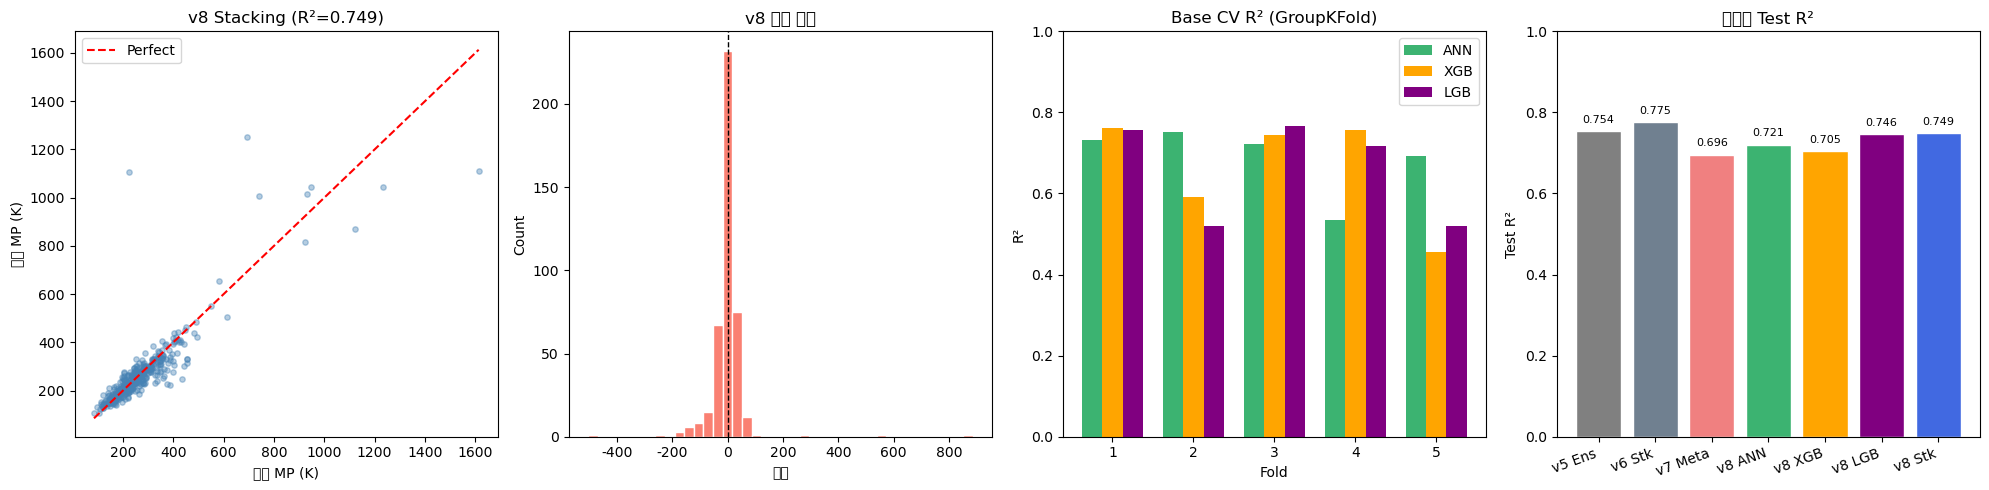

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

ax = axes[0]
ax.scatter(y_test, stack_pred, alpha=0.4, s=15, color="steelblue")
lims = [min(y_test.min(), stack_pred.min()), max(y_test.max(), stack_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect")
ax.set_xlabel("실제 MP (K)"); ax.set_ylabel("예측 MP (K)")
ax.set_title(f"v8 Stacking (R²={stack_r2:.3f})")
ax.legend()

ax = axes[1]
residuals = stack_pred - y_test
ax.hist(residuals, bins=40, color="salmon", edgecolor="white")
ax.axvline(0, color="k", linestyle="--", linewidth=1)
ax.set_xlabel("잔차"); ax.set_ylabel("Count"); ax.set_title("v8 잔차 분포")

ax = axes[2]
x_pos = np.arange(1, 6); w = 0.25
ax.bar(x_pos - w, cv_r2, w, label="ANN", color="mediumseagreen")
ax.bar(x_pos, xgb_r2_cv, w, label="XGB", color="orange")
ax.bar(x_pos + w, lgb_r2_cv, w, label="LGB", color="purple")
ax.set_xlabel("Fold"); ax.set_ylabel("R²"); ax.set_title("Base CV R² (GroupKFold)")
ax.set_ylim(0, 1); ax.legend()

ax = axes[3]
labels = ["v5 Ens", "v6 Stk", "v7 Meta", "v8 ANN", "v8 XGB", "v8 LGB", "v8 Stk"]
vals = [0.7536, 0.7754, 0.6960, ann_test_r2, xgb_test_r2, lgb_test_r2, stack_r2]
colors = ["gray", "slategray", "lightcoral", "mediumseagreen", "orange", "purple", "royalblue"]
ax.bar(labels, vals, color=colors, edgecolor="white")
ax.set_ylabel("Test R²"); ax.set_title("버전별 Test R²")
ax.set_ylim(0, 1)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=8)
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

## 13. 결과 요약 — v5~v8 비교

In [15]:
summary = pd.DataFrame({
    "버전": [
        "v5 5-seed Ensemble", "v6_stacking Meta (Ridge)", "v7 LightGBM Meta",
        "v8 ANN (augmented)", "v8 XGB (augmented)", "v8 LGB (augmented)",
        "v8 Stacking Meta (Ridge)",
    ],
    "R²": [
        "0.7536", "0.7754", "0.6960",
        f"{ann_test_r2:.4f}", f"{xgb_test_r2:.4f}", f"{lgb_test_r2:.4f}",
        f"{stack_r2:.4f}",
    ],
    "MAE (K)": [
        "32.00", "29.70", "32.40",
        f"{ann_test_mae:.2f}", f"{xgb_test_mae:.2f}", f"{lgb_test_mae:.2f}",
        f"{stack_mae:.2f}",
    ],
})
print("=== v5~v8 비교 ===")
print(f"노트북 전체 소요: {(time.time()-T0)/60:.1f}분")
print(f"Augmentation 효과: ANN {ann_test_r2 - 0.7536:+.4f}, Stacking {stack_r2 - 0.7754:+.4f}")
summary

=== v5~v8 비교 ===
노트북 전체 소요: 1.2분
Augmentation 효과: ANN -0.0329, Stacking -0.0265


,버전,R²,MAE (K)
0,v5 5-seed Ensemble,0.7536,32.00
1,v6_stacking Meta (Ridge),0.7754,29.70
2,v7 LightGBM Meta,0.6960,32.40
3,v8 ANN (augmented),0.7207,32.65
4,v8 XGB (augmented),0.7049,32.15
5,v8 LGB (augmented),0.7460,32.69
6,v8 Stacking Meta (Ridge),0.7489,30.12
